## Employee Job Change Prediction using Machine Learning

**IMPORTING NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

**IMPORT DATA FROM CSV FILE**

In [2]:
import os
print(os.getcwd())

C:\Users\HP\Data_Science\venv\capstone project


In [3]:
df = pd.read_csv('aug_train (1).csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 3.

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])

gender                 4508
enrolled_university     386
education_level         460
major_discipline       2813
experience               65
company_size           5938
company_type           6140
last_new_job            423
dtype: int64


**DATA VISUALIZATION**

target
0.0    14381
1.0     4777
Name: count, dtype: int64


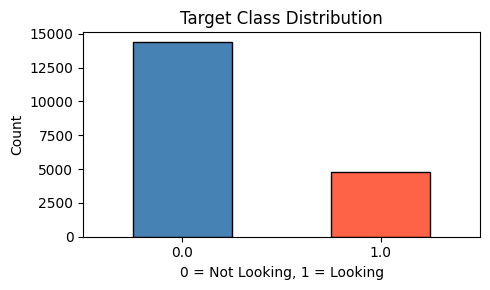

In [6]:
print(df['target'].value_counts())

plt.figure(figsize=(5, 3))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Target Class Distribution')
plt.xlabel('0 = Not Looking, 1 = Looking')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

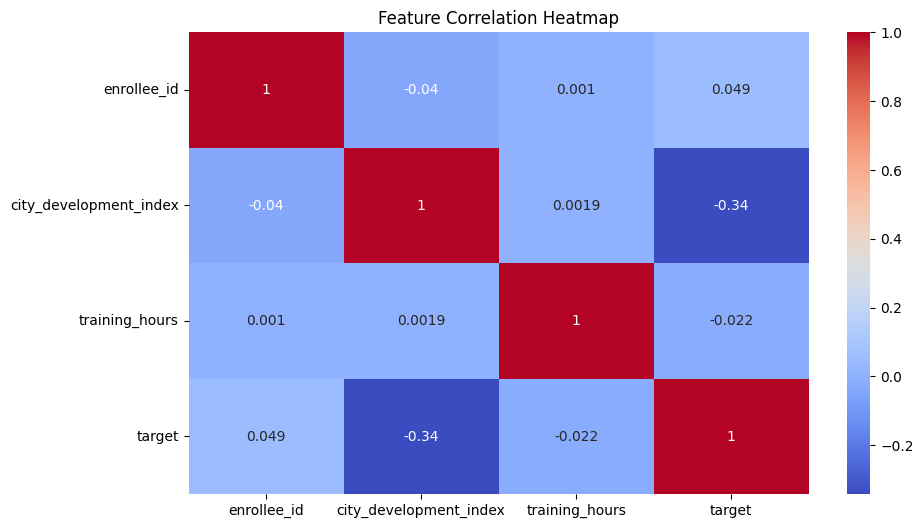

In [7]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
df.drop(columns=['enrollee_id'], inplace=True)
print('enrollee_id dropped')

enrollee_id dropped


In [9]:
categorical_cols = [
    'city', 'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'major_discipline', 'experience',
    'company_size', 'company_type', 'last_new_job'
]

# Fill categorical with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numeric with median
df['city_development_index'].fillna(df['city_development_index'].median(), inplace=True)
df['training_hours'].fillna(df['training_hours'].median(), inplace=True)

print('Missing values filled')
print('Total missing now:', df.isnull().sum().sum())

Missing values filled
Total missing now: 20733


In [10]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Label encoding done')
df.head()

Label encoding done


,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,5,0.920,1,0,2,0,5,21,8,6,0,36,1.0
1,77,0.776,1,1,2,0,5,6,4,5,4,47,0.0
2,64,0.624,3,1,0,0,5,15,8,6,5,83,0.0
3,14,0.789,3,1,3,0,1,20,8,5,5,52,1.0
4,50,0.767,1,0,2,2,5,21,4,1,3,8,0.0


In [11]:
X = df.drop(columns=['target'])
y = df['target']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (19158, 12)
y shape: (19158,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 15326
Testing  samples : 3832


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done')

Scaling done


**LOGISTIC REGRESSION**

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print('── Logistic Regression ──')
print(f'Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['Not Looking', 'Looking']))

── Logistic Regression ──
Accuracy : 0.7774
ROC-AUC  : 0.7791

              precision    recall  f1-score   support

 Not Looking       0.80      0.94      0.86      2877
     Looking       0.61      0.30      0.40       955

    accuracy                           0.78      3832
   macro avg       0.71      0.62      0.63      3832
weighted avg       0.75      0.78      0.75      3832



**DECISION TREE**

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print('Decision Tree')
print(f'Accuracy : {accuracy_score(y_test, dt_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, dt_proba):.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=['Not Looking', 'Looking']))

Decision Tree
Accuracy : 0.7156
ROC-AUC  : 0.6361

              precision    recall  f1-score   support

 Not Looking       0.82      0.80      0.81      2877
     Looking       0.44      0.48      0.45       955

    accuracy                           0.72      3832
   macro avg       0.63      0.64      0.63      3832
weighted avg       0.72      0.72      0.72      3832



**RANDOM FOREST**

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('Random Forest')
print(f'Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Not Looking', 'Looking']))

Random Forest
Accuracy : 0.7842
ROC-AUC  : 0.7963

              precision    recall  f1-score   support

 Not Looking       0.84      0.88      0.86      2877
     Looking       0.58      0.49      0.53       955

    accuracy                           0.78      3832
   macro avg       0.71      0.69      0.70      3832
weighted avg       0.77      0.78      0.78      3832



**GRADIENT BOOSTING**

In [17]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

gb_pred  = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print('Gradient Boosting')
print(f'Accuracy : {accuracy_score(y_test, gb_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, gb_proba):.4f}')
print()
print(classification_report(y_test, gb_pred, target_names=['Not Looking', 'Looking']))

Gradient Boosting
Accuracy : 0.7983
ROC-AUC  : 0.8139

              precision    recall  f1-score   support

 Not Looking       0.86      0.87      0.87      2877
     Looking       0.60      0.59      0.59       955

    accuracy                           0.80      3832
   macro avg       0.73      0.73      0.73      3832
weighted avg       0.80      0.80      0.80      3832



**SUPPORT VECTOR MACHINE**

In [18]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

svm_pred  = svm.predict(X_test_scaled)
svm_proba = svm.predict_proba(X_test_scaled)[:, 1]

print('SVM')
print(f'Accuracy : {accuracy_score(y_test, svm_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, svm_proba):.4f}')
print()
print(classification_report(y_test, svm_pred, target_names=['Not Looking', 'Looking']))

SVM
Accuracy : 0.7816
ROC-AUC  : 0.7749

              precision    recall  f1-score   support

 Not Looking       0.83      0.89      0.86      2877
     Looking       0.58      0.45      0.51       955

    accuracy                           0.78      3832
   macro avg       0.70      0.67      0.68      3832
weighted avg       0.77      0.78      0.77      3832



In [19]:
results = {
    'Logistic Regression': {'Accuracy': accuracy_score(y_test, lr_pred),  'ROC-AUC': roc_auc_score(y_test, lr_proba)},
    'Decision Tree':       {'Accuracy': accuracy_score(y_test, dt_pred),  'ROC-AUC': roc_auc_score(y_test, dt_proba)},
    'Random Forest':       {'Accuracy': accuracy_score(y_test, rf_pred),  'ROC-AUC': roc_auc_score(y_test, rf_proba)},
    'Gradient Boosting':   {'Accuracy': accuracy_score(y_test, gb_pred),  'ROC-AUC': roc_auc_score(y_test, gb_proba)},
    'SVM':                 {'Accuracy': accuracy_score(y_test, svm_pred), 'ROC-AUC': roc_auc_score(y_test, svm_proba)},
}

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,ROC-AUC
Gradient Boosting,0.798278,0.813854
Random Forest,0.784186,0.796257
SVM,0.781576,0.774886
Logistic Regression,0.777401,0.779073
Decision Tree,0.715553,0.636074


**COMPARE ALL ACCURACY**

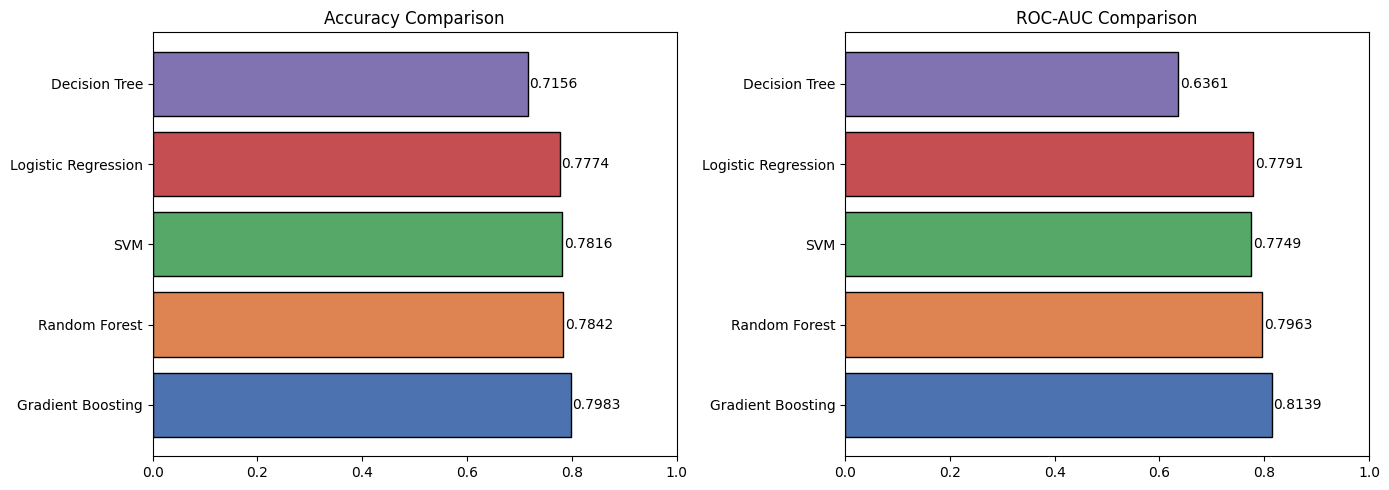

In [20]:
model_names = results_df.index.tolist()
accuracies  = results_df['Accuracy'].tolist()
roc_aucs    = results_df['ROC-AUC'].tolist()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
bars = axes[0].barh(model_names, accuracies, color=colors, edgecolor='black')
for bar, val in zip(bars, accuracies):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlim(0, 1)

# ROC-AUC
bars2 = axes[1].barh(model_names, roc_aucs, color=colors, edgecolor='black')
for bar, val in zip(bars2, roc_aucs):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

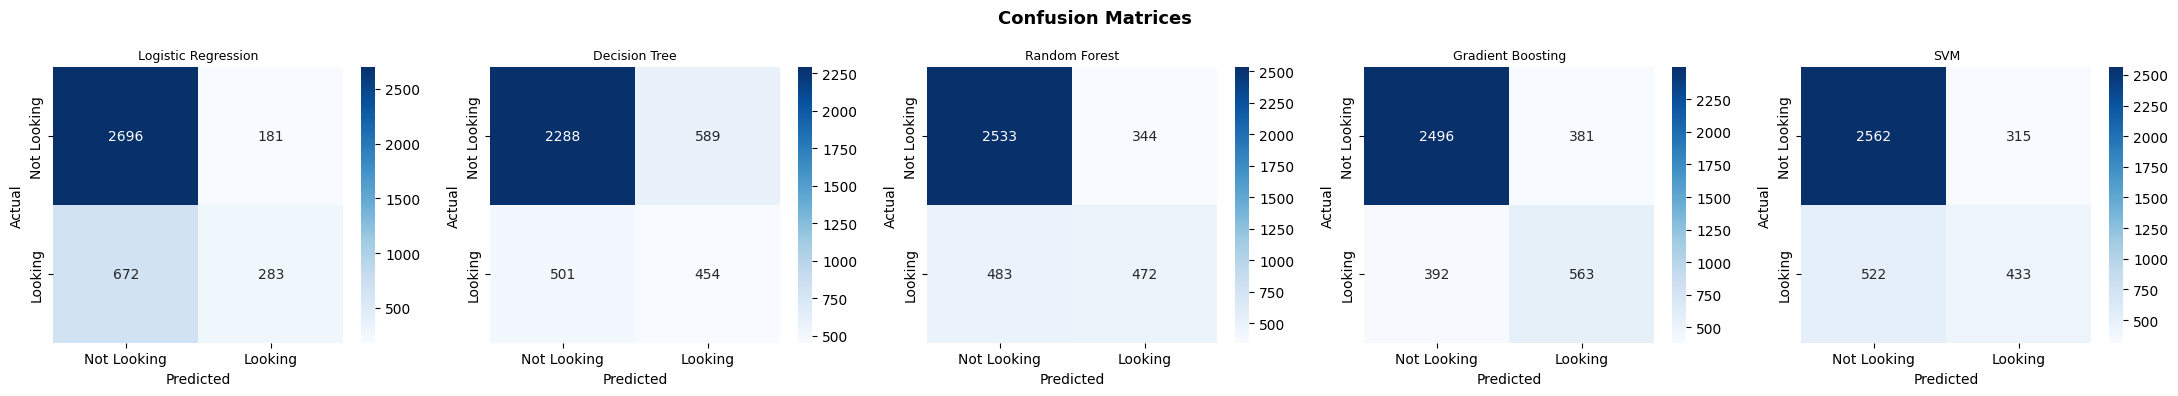

In [21]:
all_preds = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree',       dt_pred),
    ('Random Forest',       rf_pred),
    ('Gradient Boosting',   gb_pred),
    ('SVM',                 svm_pred),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pred) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Looking', 'Looking'],
                yticklabels=['Not Looking', 'Looking'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

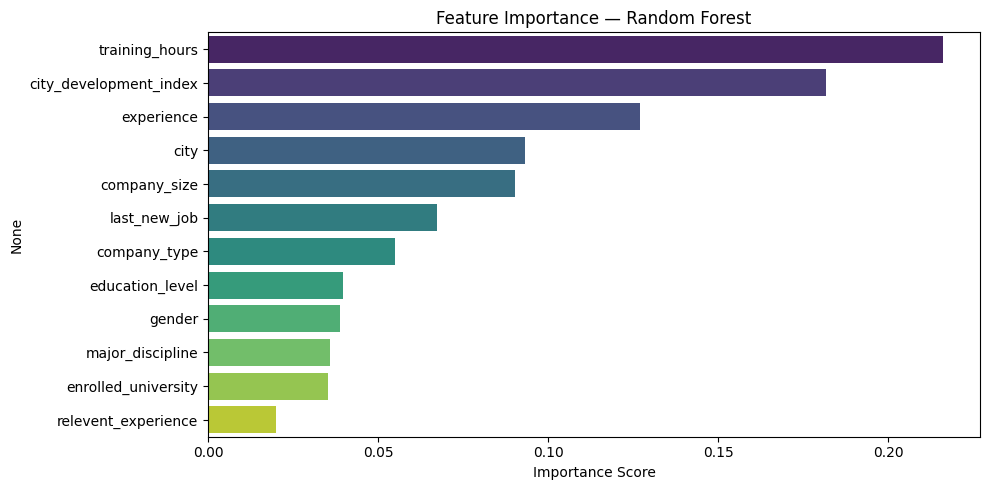

training_hours            0.216137
city_development_index    0.181729
experience                0.126961
city                      0.093306
company_size              0.090090
last_new_job              0.067232
company_type              0.054792
education_level           0.039605
gender                    0.038837
major_discipline          0.035899
enrolled_university       0.035324
relevent_experience       0.020089
dtype: float64


In [22]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

In [23]:
import joblib
joblib.dump(gb, "gb_model.joblib")
joblib.dump(X.columns.tolist(), "feature_cols.joblib")

['feature_cols.joblib']

In [24]:
joblib.load("gb_model.joblib")

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Conclusion

#### The Employee Job Change Prediction model was successfully built using multiple machine learning algorithms. 
#### After evaluation, Random Forest provided the highest predictive performance.
#### The model can assist organizations in predicting employee job change intentions and making data-driven retention decisions